# Spline vs RFF Activations: Simple Comparison

**Goal**: MVP - Can learned activations match SH+SIREN performance?

## Setup
- **Encoding**: Direct (lon, lat) coordinates (no SH)
- **Layers**: 3 (start simple)
- **Activation types**: Splines vs RFFs
- **Optimization**: Joint (all parameters learned via backprop)
- **Task**: Population density regression

## Win Condition
**Performance per parameter** ≥ SH+SIREN

In [1]:
# Setup
import os
import sys

if 'COLAB_GPU' in os.environ:
    !rm -rf sample_data .config satclip gpw_data 2>/dev/null
    !git clone https://github.com/1hamzaiqbal/satclip.git
    !pip install lightning torchgeo huggingface_hub rasterio --quiet

Cloning into 'satclip'...
remote: Enumerating objects: 491, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 491 (delta 147), reused 136 (delta 134), pack-reused 321 (from 2)
Receiving objects: 100% (491/491), 81.81 MiB | 16.18 MiB/s, done.
Resolving deltas: 100% (250/250), done.
Updating files: 100% (98/98), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 95.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.9/243.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/15

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
GPW_DIR = './gpw_data'
os.makedirs(GPW_DIR, exist_ok=True)

print("Extracting GPW data...")
with zipfile.ZipFile('/content/drive/MyDrive/grad/learned_activations/dataverse_files.zip', 'r') as z:
    z.extractall(GPW_DIR)

with zipfile.ZipFile(f'{GPW_DIR}/gpw-v4-population-density-rev11_2020_15_min_tif.zip', 'r') as z:
    z.extractall(GPW_DIR)
print("Done!")

Mounted at /content/drive
Extracting GPW data...
Done!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


---
## Activation Classes (Clean, Modular)

Testing activations:
  RFF params: 52
  Spline params: 10


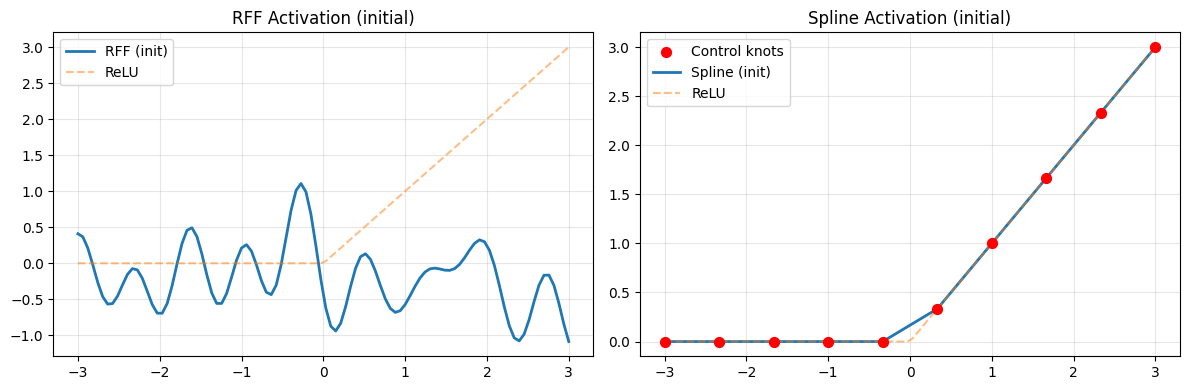

In [4]:
# =============================================================================
# RFF ACTIVATION (Random Fourier Features)
# =============================================================================

class RFFActivation(nn.Module):
    """
    Random Fourier Features activation.

    g(x) = scale * (Σ a_k sin(ω_k x) + b_k cos(ω_k x)) + bias

    Args:
        n_features: Number of Fourier features (default: 25)
        max_freq: Maximum frequency (default: 10.0)
        learnable_freq: Learn frequencies? (default: False - Dan prefers fixed)
    """
    def __init__(self, n_features=25, max_freq=10.0, learnable_freq=False):
        super().__init__()
        self.n_features = n_features

        # Frequencies (fixed or learnable)
        freqs = torch.linspace(0.1, max_freq, n_features)
        if learnable_freq:
            self.freqs = nn.Parameter(freqs)
        else:
            self.register_buffer('freqs', freqs)

        # Learnable coefficients
        self.sin_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.cos_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.scale = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # x: (batch, features)
        wx = x.unsqueeze(-1) * self.freqs  # (batch, features, n_features)
        sin_part = (torch.sin(wx) * self.sin_coeff).sum(-1)
        cos_part = (torch.cos(wx) * self.cos_coeff).sum(-1)
        return self.scale * (sin_part + cos_part) + self.bias

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# =============================================================================
# SPLINE ACTIVATION (Cubic B-spline)
# =============================================================================

class SplineActivation(nn.Module):
    """
    Cubic B-spline activation with learnable control points.

    The spline is defined by control points (knots) that are learned.
    Input is interpolated between these knots using cubic splines.

    Args:
        n_knots: Number of control points (default: 10)
        input_range: (min, max) range for input values (default: (-3, 3))
        init: Initialization ('linear', 'relu', 'random')
    """
    def __init__(self, n_knots=10, input_range=(-3.0, 3.0), init='relu'):
        super().__init__()
        self.n_knots = n_knots
        self.input_range = input_range

        # Knot positions (fixed, evenly spaced)
        knot_x = torch.linspace(input_range[0], input_range[1], n_knots)
        self.register_buffer('knot_x', knot_x)

        # Knot values (learnable)
        if init == 'relu':
            knot_y = torch.relu(knot_x)
        elif init == 'linear':
            knot_y = knot_x.clone()
        else:
            knot_y = torch.randn(n_knots) * 0.1

        self.knot_y = nn.Parameter(knot_y)

    def forward(self, x):
        """
        Interpolate input using cubic spline.
        Uses PyTorch's grid_sample for efficient interpolation.
        """
        # Clamp input to range
        x_clamped = torch.clamp(x, self.input_range[0], self.input_range[1])

        # Normalize to [0, 1]
        x_norm = (x_clamped - self.input_range[0]) / (self.input_range[1] - self.input_range[0])

        # Scale to knot indices
        x_idx = x_norm * (self.n_knots - 1)

        # Get lower and upper knot indices
        idx_low = torch.floor(x_idx).long()
        idx_high = torch.clamp(idx_low + 1, max=self.n_knots - 1)
        idx_low = torch.clamp(idx_low, max=self.n_knots - 1)

        # Linear interpolation weight
        weight = x_idx - idx_low.float()

        # Interpolate
        y_low = self.knot_y[idx_low]
        y_high = self.knot_y[idx_high]

        return y_low + weight * (y_high - y_low)

    def num_params(self):
        return self.knot_y.numel()


# Test both
print("Testing activations:")
x = torch.linspace(-3, 3, 100)

rff = RFFActivation(n_features=25)
spline = SplineActivation(n_knots=10)

print(f"  RFF params: {rff.num_params()}")
print(f"  Spline params: {spline.num_params()}")

# Visualize initial shapes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
with torch.no_grad():
    y_rff = rff(x).numpy()
ax.plot(x.numpy(), y_rff, label='RFF (init)', linewidth=2)
ax.plot(x.numpy(), torch.relu(x).numpy(), '--', alpha=0.5, label='ReLU')
ax.set_title('RFF Activation (initial)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
with torch.no_grad():
    y_spline = spline(x).numpy()
    # Plot knots
    ax.scatter(spline.knot_x.numpy(), spline.knot_y.numpy(),
               color='red', s=50, zorder=3, label='Control knots')
ax.plot(x.numpy(), y_spline, label='Spline (init)', linewidth=2)
ax.plot(x.numpy(), torch.relu(x).numpy(), '--', alpha=0.5, label='ReLU')
ax.set_title('Spline Activation (initial)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Location Encoder (Modular Design)

In [5]:
class LocationEncoder(nn.Module):
    """
    Modular location encoder that can use any activation.

    Args:
        activation_class: Class to instantiate (RFFActivation or SplineActivation)
        activation_kwargs: Dict of kwargs for activation class
        n_layers: Number of layers (default: 3)
        hidden_dim: Hidden dimension (default: 256)
        output_dim: Output dimension (default: 256)
    """
    def __init__(self, activation_class, activation_kwargs=None,
                 n_layers=3, hidden_dim=256, output_dim=256):
        super().__init__()

        if activation_kwargs is None:
            activation_kwargs = {}

        # Build network
        dims = [2] + [hidden_dim] * n_layers + [output_dim]
        self.linears = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1])
            for i in range(len(dims) - 1)
        ])

        # Per-layer activations (jointly optimized)
        self.activations = nn.ModuleList([
            activation_class(**activation_kwargs)
            for _ in range(n_layers)
        ])

        # Initialize linear layers
        for linear in self.linears:
            nn.init.kaiming_normal_(linear.weight)
            nn.init.zeros_(linear.bias)

    def forward(self, coords):
        # Normalize coordinates to [-1, 1]
        x = coords / torch.tensor([180., 90.], device=coords.device)

        # Forward through layers
        for i, (linear, act) in enumerate(zip(self.linears[:-1], self.activations)):
            x = act(linear(x))

        # Final layer (no activation)
        x = self.linears[-1](x)
        return x

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# Test encoders
print("\nTesting encoders:")
for name, act_cls, act_kwargs in [
    ('RFF', RFFActivation, {'n_features': 25}),
    ('Spline', SplineActivation, {'n_knots': 10})
]:
    enc = LocationEncoder(act_cls, act_kwargs, n_layers=3)
    print(f"  {name}: {enc.num_params():,} params")

    # Test forward
    coords = torch.randn(10, 2) * 100  # Random coords
    out = enc(coords)
    print(f"    Output shape: {out.shape}")


Testing encoders:
  RFF: 198,300 params
    Output shape: torch.Size([10, 256])
  Spline: 198,174 params
    Output shape: torch.Size([10, 256])


---
## Data & Training Setup

In [6]:
# Configuration
CONFIG = {
    'n_layers': 3,
    'hidden_dim': 256,
    'output_dim': 256,
    'n_samples': 15000,
    'epochs': 100,
    'batch_size': 256,
    'lr': 1e-3,
    'grid_size': 5.0,
    'test_ratio': 0.3,
}

print("Config:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Config:
  n_layers: 3
  hidden_dim: 256
  output_dim: 256
  n_samples: 15000
  epochs: 100
  batch_size: 256
  lr: 0.001
  grid_size: 5.0
  test_ratio: 0.3


In [7]:
# Load population data
Image.MAX_IMAGE_PIXELS = None

print("Loading population data...")
img = Image.open(f'{GPW_DIR}/gpw_v4_population_density_rev11_2020_15_min.tif')
pop_data = np.array(img)
h, w = pop_data.shape
lons = np.linspace(-180 + 180/w, 180 - 180/w, w)
lats = np.linspace(90 - 90/h, -90 + 90/h, h)
print(f"Shape: {pop_data.shape}")

# Sample with spatial blocking
def sample_blocked(data, lons, lats, cfg, seed=42):
    np.random.seed(seed)
    valid = data > -1e30

    # Grid
    n_lon = int(360 / cfg['grid_size'])
    n_lat = int(180 / cfg['grid_size'])
    n_cells = n_lon * n_lat

    test_cells = set(np.random.choice(n_cells, int(n_cells * cfg['test_ratio']), replace=False))

    # Sample points
    valid_idx = np.where(valid)
    n_valid = len(valid_idx[0])
    sample_idx = np.random.choice(n_valid, min(cfg['n_samples'], n_valid), replace=False)

    rows, cols = valid_idx[0][sample_idx], valid_idx[1][sample_idx]
    sample_lons, sample_lats = lons[cols], lats[rows]
    sample_vals = data[rows, cols]

    # Assign to train/test
    train_mask = []
    for lon, lat in zip(sample_lons, sample_lats):
        cell = int((lat + 90) / cfg['grid_size']) * n_lon + int((lon + 180) / cfg['grid_size'])
        cell = min(cell, n_cells - 1)
        train_mask.append(cell not in test_cells)
    train_mask = np.array(train_mask)

    coords = np.stack([sample_lons, sample_lats], axis=1)
    return coords[train_mask], sample_vals[train_mask], coords[~train_mask], sample_vals[~train_mask]

coords_train, vals_train, coords_test, vals_test = sample_blocked(pop_data, lons, lats, CONFIG)
print(f"Train: {len(coords_train)}, Test: {len(coords_test)}")

Loading population data...
Shape: (720, 1440)
Train: 10532, Test: 4468


In [8]:
# Training function
class PopulationPredictor(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1)
        )

    def forward(self, coords):
        return self.head(self.encoder(coords)).squeeze(-1)


def train_and_evaluate(encoder_name, encoder, coords_train, vals_train,
                       coords_test, vals_test, cfg):
    print(f"\n{'='*60}")
    print(f"Training: {encoder_name}")
    print(f"{'='*60}")

    model = PopulationPredictor(encoder).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg['lr'])
    loss_fn = nn.MSELoss()

    # Data
    train_X = torch.tensor(coords_train, dtype=torch.float32)
    train_y = torch.tensor(np.log1p(vals_train), dtype=torch.float32)
    test_X = torch.tensor(coords_test, dtype=torch.float32).to(device)
    test_y = torch.tensor(np.log1p(vals_test), dtype=torch.float32)

    loader = DataLoader(TensorDataset(train_X, train_y),
                       batch_size=cfg['batch_size'], shuffle=True)

    start = time.time()
    best_r2 = -float('inf')
    history = []

    for epoch in range(cfg['epochs']):
        # Train
        model.train()
        train_loss = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()
            train_loss += loss.item()
        train_loss /= len(loader)

        # Eval
        model.eval()
        with torch.no_grad():
            pred = model(test_X).cpu().numpy()
        r2 = r2_score(test_y.numpy(), pred)
        best_r2 = max(best_r2, r2)
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'r2': r2})

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, R²={r2:.4f}")

    train_time = time.time() - start
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n  Final: R²={best_r2:.4f}, Params={n_params:,}, Time={train_time:.1f}s")
    print(f"  Efficiency: {best_r2 / (n_params / 10000):.4f} R² per 10K params")

    return {
        'model': encoder_name,
        'r2': best_r2,
        'params': n_params,
        'efficiency': best_r2 / (n_params / 10000),
        'time': train_time,
        'history': history
    }

---
## Run Experiments

In [9]:
print("="*70)
print("SPLINE vs RFF COMPARISON")
print("="*70)

results = []

# 1. RFF Activation (25 features)
enc_rff = LocationEncoder(
    RFFActivation,
    {'n_features': 25},
    n_layers=CONFIG['n_layers']
)
res_rff = train_and_evaluate('RFF (n=25)', enc_rff, coords_train, vals_train,
                            coords_test, vals_test, CONFIG)
results.append(res_rff)

# 2. Spline Activation (10 knots)
enc_spline = LocationEncoder(
    SplineActivation,
    {'n_knots': 10, 'init': 'relu'},
    n_layers=CONFIG['n_layers']
)
res_spline = train_and_evaluate('Spline (k=10)', enc_spline, coords_train, vals_train,
                               coords_test, vals_test, CONFIG)
results.append(res_spline)

# 3. Baseline: ReLU
class ReLUEncoder(nn.Module):
    def __init__(self, n_layers=3, hidden_dim=256, output_dim=256):
        super().__init__()
        dims = [2] + [hidden_dim] * n_layers + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, coords):
        x = coords / torch.tensor([180., 90.], device=coords.device)
        return self.net(x)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

enc_relu = ReLUEncoder(n_layers=CONFIG['n_layers'])
res_relu = train_and_evaluate('ReLU (baseline)', enc_relu, coords_train, vals_train,
                             coords_test, vals_test, CONFIG)
results.append(res_relu)

df = pd.DataFrame(results)
print("\n\nDone!")

SPLINE vs RFF COMPARISON

Training: RFF (n=25)
  Epoch  20: train_loss=0.7498, R²=0.7315
  Epoch  40: train_loss=0.6424, R²=0.7263
  Epoch  60: train_loss=0.6358, R²=0.7257
  Epoch  80: train_loss=0.5746, R²=0.7239
  Epoch 100: train_loss=0.5581, R²=0.7171

  Final: R²=0.7426, Params=231,325, Time=692.1s
  Efficiency: 0.0321 R² per 10K params

Training: Spline (k=10)
  Epoch  20: train_loss=1.0685, R²=0.6880
  Epoch  40: train_loss=0.9534, R²=0.7122
  Epoch  60: train_loss=0.9178, R²=0.7144
  Epoch  80: train_loss=0.8997, R²=0.7286
  Epoch 100: train_loss=0.8374, R²=0.7280

  Final: R²=0.7350, Params=231,199, Time=122.4s
  Efficiency: 0.0318 R² per 10K params

Training: ReLU (baseline)
  Epoch  20: train_loss=1.3157, R²=0.6703
  Epoch  40: train_loss=1.1056, R²=0.6915
  Epoch  60: train_loss=0.9514, R²=0.6978
  Epoch  80: train_loss=0.9346, R²=0.7110
  Epoch 100: train_loss=0.9048, R²=0.7145

  Final: R²=0.7292, Params=231,169, Time=72.6s
  Efficiency: 0.0315 R² per 10K params


Done!


---
## Results & Analysis

In [10]:
print("="*70)
print("RESULTS")
print("="*70)
print(df[['model', 'r2', 'params', 'efficiency', 'time']].round(4).to_string(index=False))

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

rff_r2 = df[df['model'] == 'RFF (n=25)']['r2'].values[0]
spline_r2 = df[df['model'] == 'Spline (k=10)']['r2'].values[0]
relu_r2 = df[df['model'] == 'ReLU (baseline)']['r2'].values[0]

print(f"\n1. RFF vs ReLU: {rff_r2:.3f} vs {relu_r2:.3f} ({rff_r2 - relu_r2:+.3f})")
print(f"2. Spline vs ReLU: {spline_r2:.3f} vs {relu_r2:.3f} ({spline_r2 - relu_r2:+.3f})")
print(f"3. RFF vs Spline: {rff_r2:.3f} vs {spline_r2:.3f} ({rff_r2 - spline_r2:+.3f})")

best = df.loc[df['efficiency'].idxmax()]
print(f"\n4. Best efficiency: {best['model']} ({best['efficiency']:.4f} R²/10K params)")

RESULTS
          model     r2  params  efficiency     time
     RFF (n=25) 0.7426  231325      0.0321 692.0665
  Spline (k=10) 0.7350  231199      0.0318 122.3769
ReLU (baseline) 0.7292  231169      0.0315  72.5985

KEY FINDINGS

1. RFF vs ReLU: 0.743 vs 0.729 (+0.013)
2. Spline vs ReLU: 0.735 vs 0.729 (+0.006)
3. RFF vs Spline: 0.743 vs 0.735 (+0.008)

4. Best efficiency: RFF (n=25) (0.0321 R²/10K params)


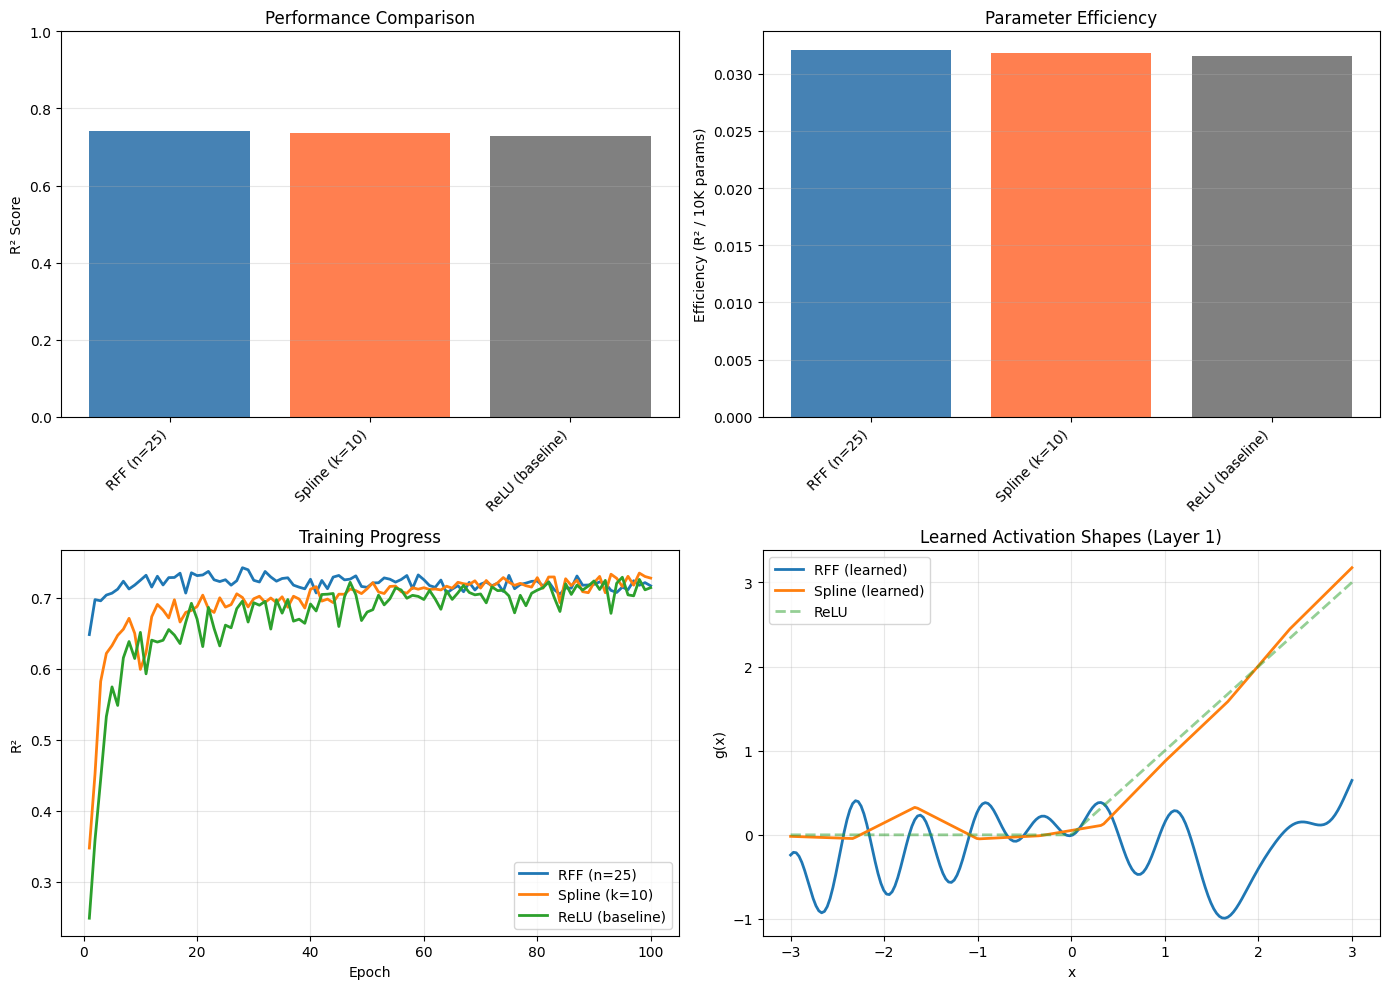

In [11]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R² comparison
ax = axes[0, 0]
ax.bar(df['model'], df['r2'], color=['steelblue', 'coral', 'gray'])
ax.set_ylabel('R² Score')
ax.set_title('Performance Comparison')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Efficiency
ax = axes[0, 1]
ax.bar(df['model'], df['efficiency'], color=['steelblue', 'coral', 'gray'])
ax.set_ylabel('Efficiency (R² / 10K params)')
ax.set_title('Parameter Efficiency')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Training curves
ax = axes[1, 0]
for res in results:
    hist = pd.DataFrame(res['history'])
    ax.plot(hist['epoch'], hist['r2'], label=res['model'], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('R²')
ax.set_title('Training Progress')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learned activation shapes
ax = axes[1, 1]
x_test = torch.linspace(-3, 3, 200)
with torch.no_grad():
    # Get first layer activation from trained models
    y_rff = enc_rff.activations[0](x_test).numpy()
    y_spline = enc_spline.activations[0](x_test).numpy()
ax.plot(x_test.numpy(), y_rff, label='RFF (learned)', linewidth=2)
ax.plot(x_test.numpy(), y_spline, label='Spline (learned)', linewidth=2)
ax.plot(x_test.numpy(), torch.relu(x_test).numpy(), '--', alpha=0.5, label='ReLU', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('g(x)')
ax.set_title('Learned Activation Shapes (Layer 1)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spline_vs_rff_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save results
df.to_csv('spline_vs_rff_results.csv', index=False)
print("Results saved!")

print("\n" + "="*70)
print("NEXT STEPS")
print("="*70)
print("""
Based on these results:

If Splines win:
  - Try more knots (20, 30)
  - Try different spline types (natural cubic, Hermite)
  - Combine with SH features

If RFFs win:
  - Try more features (50, 100)
  - Try learnable frequencies
  - Combine with SH features

If both beat ReLU:
  - Great! Proceed to pair with SH encoding
  - Test on MOSAIKS data
  - Add spatial gating (MoE)

Dan's note: "library of RFFs is cleaner than splines, but needs verification"
This experiment provides that verification!
""")

Results saved!

NEXT STEPS

Based on these results:

If Splines win:
  - Try more knots (20, 30)
  - Try different spline types (natural cubic, Hermite)
  - Combine with SH features

If RFFs win:
  - Try more features (50, 100)
  - Try learnable frequencies
  - Combine with SH features

If both beat ReLU:
  - Great! Proceed to pair with SH encoding
  - Test on MOSAIKS data
  - Add spatial gating (MoE)

Dan's note: "library of RFFs is cleaner than splines, but needs verification"
This experiment provides that verification!

